# 勇者傳說 — Overworld Character Back View Generator V2 (T4 GPU)

Generate **back-facing standing pose** character sprites using **txt2img** (NOT img2img).

**Why txt2img?** img2img with front-facing init images preserves the face orientation
too strongly — even at strength=0.65+, the model reproduces front views. txt2img gives
full creative freedom for the back perspective while we ensure style consistency via:
1. Same SDXL + pixel-art-xl LoRA pipeline as V3 front views
2. Prompts with **explicit color descriptions** matching each character's outfit
3. **Color similarity scoring** — candidates ranked by palette match to front image
4. Strong negative prompt excluding front-face, eyes, looking at viewer

| Category | Count | Final Size | Gen Size | Steps |
|----------|-------|------------|----------|-------|
| Party members | 8 | 64×96 | 512×768 | 30 |
| NPC types | 5 | 64×96 | 512×768 | 28 |
| Guard base | 1 | 64×96 | 512×768 | 28 |

**Requires**: Front-facing sprites in `overworld_characters/` (for color comparison only).

**Output**: `overworld_characters/char_hero_back.png` etc. (14 RGBA PNGs)  
**Import**: `bash scripts/import_colab_assets.sh ~/Downloads/owc_back_v2_output`

## 0. Cleanup

In [1]:
import os, shutil, glob
from pathlib import Path

try:
    from google.colab import drive
    if not os.path.ismount('/content/drive'):
        drive.mount('/content/drive')
    ON_COLAB = True
except ImportError:
    ON_COLAB = False

GDRIVE_BASE = Path('/content/drive/MyDrive/ai-rpg-game')
OUTPUT_BASE = GDRIVE_BASE / 'outputs' if ON_COLAB else Path('outputs')

# Delete old progress files
deleted = 0
for pattern in ['_progress_owc_back_*.json']:
    for f in OUTPUT_BASE.glob(pattern):
        f.unlink()
        deleted += 1
        print(f'  Deleted: {f.name}')

# Delete old back images (keep front images!)
back_dir = OUTPUT_BASE / 'overworld_characters'
if back_dir.exists():
    for f in back_dir.glob('*_back.png'):
        f.unlink()
        deleted += 1
        print(f'  Deleted: {f.name}')

print(f'Cleaned {deleted} items.' if deleted else 'Nothing to clean up.')

Mounted at /content/drive
Nothing to clean up.


## 1. Setup

In [2]:
!pip install -q "numpy<2" scipy
!pip install -q diffusers transformers accelerate safetensors "Pillow>=10,<12" rembg onnxruntime

import gc, json, time
from pathlib import Path

MODELS_DIR = GDRIVE_BASE / 'models' if ON_COLAB else Path('models')

for d in [OUTPUT_BASE, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

import torch
assert torch.cuda.is_available(), 'ERROR: GPU required! Runtime → Change runtime type → T4 GPU'
name = torch.cuda.get_device_name(0)
props = torch.cuda.get_device_properties(0)
vram = (getattr(props, 'total_memory', None) or getattr(props, 'total_mem', 0)) / 1024**3
DEVICE = 'cuda'
DTYPE = torch.float16
print(f'GPU: {name} ({vram:.1f} GB VRAM)')
print(f'Output: {OUTPUT_BASE}')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 47.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tobler 0.13.0 requires numpy>=2.0, but y

## 2. Utilities

In [3]:
import numpy as np
from scipy import ndimage

class ProgressTracker:
    def __init__(self, name, base_dir):
        self.path = Path(base_dir) / f'_progress_{name}.json'
        self.done = set()
        if self.path.exists():
            try: self.done = set(json.loads(self.path.read_text()))
            except: pass
    def is_done(self, key): return key in self.done
    def mark_done(self, key):
        self.done.add(key)
        self.path.write_text(json.dumps(sorted(self.done)))
    def summary(self, total): return f'{len(self.done)}/{total} done'

def free_vram():
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

def print_vram(label=''):
    if torch.cuda.is_available():
        used = torch.cuda.memory_allocated() / 1024**3
        total_gb = (getattr(torch.cuda.get_device_properties(0), 'total_memory', 0)) / 1024**3
        print(f'VRAM {label}: {used:.1f} / {total_gb:.1f} GB')

def largest_connected_component(rgba_img):
    arr = np.array(rgba_img)
    alpha = arr[:, :, 3]
    mask = alpha > 30
    struct = ndimage.generate_binary_structure(2, 2)
    dilated = ndimage.binary_dilation(mask, struct, iterations=3)
    labeled, n_features = ndimage.label(dilated, structure=struct)
    if n_features <= 1: return rgba_img
    sizes = ndimage.sum(mask, labeled, range(1, n_features + 1))
    largest_label = np.argmax(sizes) + 1
    keep_mask = (labeled == largest_label) & mask
    result = arr.copy()
    result[~keep_mask] = [0, 0, 0, 0]
    from PIL import Image
    return Image.fromarray(result)

def quality_score(rgba_img, target_w=64, target_h=96):
    arr = np.array(rgba_img)
    alpha = arr[:, :, 3]
    mask = alpha > 30
    total_pixels = target_w * target_h
    filled_pixels = np.sum(mask)
    fill_ratio = filled_pixels / total_pixels
    rows_with_content = np.any(mask, axis=1)
    if not np.any(rows_with_content): return 0.0, 0.0, 0.0
    first_row = np.argmax(rows_with_content)
    last_row = len(rows_with_content) - np.argmax(rows_with_content[::-1]) - 1
    height_ratio = (last_row - first_row + 1) / rgba_img.height
    return fill_ratio * height_ratio, fill_ratio, height_ratio

MIN_FILL_RATIO = 0.15
MIN_HEIGHT_RATIO = 0.50
print('Utilities ready')

Utilities ready


## 3. Verify Front Images (for color comparison)

Front images are used ONLY for color similarity scoring, NOT as img2img input.

In [4]:
from PIL import Image

FRONT_DIR = OUTPUT_BASE / 'overworld_characters'

ALL_KEYS = [
    'char_hero', 'char_elf', 'char_treant', 'char_beast',
    'char_merfolk', 'char_giant', 'char_dwarf', 'char_undead',
    'char_npc_shop', 'char_npc_quest', 'char_npc_save', 'char_npc_info', 'char_npc_inn',
    'char_guard',
]

found = 0
for key in ALL_KEYS:
    p = FRONT_DIR / f'{key}.png'
    if p.exists():
        found += 1
        print(f'  OK  {key}')
    else:
        print(f'  MISSING  {key} (color comparison disabled for this char)')

print(f'\n{found}/{len(ALL_KEYS)} front images found for color comparison.')
if found == 0:
    print('WARNING: No front images. Color similarity scoring will be disabled.')
    print('Back views will still generate, but color consistency is not guaranteed.')

  OK  char_hero
  OK  char_elf
  OK  char_treant
  OK  char_beast
  OK  char_merfolk
  OK  char_giant
  OK  char_dwarf
  OK  char_undead
  OK  char_npc_shop
  OK  char_npc_quest
  OK  char_npc_save
  MISSING  char_npc_info (color comparison disabled for this char)
  OK  char_npc_inn
  OK  char_guard

13/14 front images found for color comparison.


## 4. Back-View Prompt Data

**Key design decisions:**
- `from behind, back of head, rear view, facing away` — multiple synonyms to strongly bias perspective
- Explicit color keywords matching the front outfit (crimson cape, blue armor, etc.)
- Elements visible from behind emphasized: cape flow, hair, back of helmet
- Front-specific elements removed: face, eyes, chest emblem
- Strong negative prompt: `front view, face, eyes, looking at viewer, facing camera`

In [5]:
# CRITICAL: Strong negative against front-facing to force genuine back views
NEGATIVE = (
    'front view, face, eyes, looking at viewer, facing camera, facing forward, '
    'portrait, frontal, '
    'blurry, text, watermark, signature, multiple characters, duplicate, group, '
    'sprite sheet, multiple views, multiple poses, turnaround, '
    'realistic photo, complex background, border, frame, grid'
)

# txt2img back-view prompts — explicit colors to match front views
ENTRIES = [
    # ── Party members (30 steps) ──
    {'name': 'char_hero', 'steps': 30, 'prompt':
     'pixel art, single chibi character seen from behind, back of head visible, '
     'young prince swordsman, golden blonde hair, long flowing deep crimson red cape, '
     'blue steel armor with shoulder pauldrons, sword sheathed at hip, '
     'standing idle facing away from viewer, dark solid background'},

    {'name': 'char_elf', 'steps': 30, 'prompt':
     'pixel art, single chibi character seen from behind, back of head visible, '
     'elf forest ranger, pointed ears, long blonde hair, flowing green cloak, '
     'dark green leather armor, wooden bow and quiver on back, '
     'standing idle facing away from viewer, dark solid background'},

    {'name': 'char_treant', 'steps': 30, 'prompt':
     'pixel art, single chibi character seen from behind, back of head visible, '
     'ancient tree sage, bark texture body, dark green flowing cape, '
     'emerald green robe, wooden gnarled staff, '
     'standing idle facing away from viewer, dark solid background'},

    {'name': 'char_beast', 'steps': 30, 'prompt':
     'pixel art, single chibi character seen from behind, back of head visible, '
     'fierce beast monk, muscular broad back, red bandana headband, '
     'orange tunic, bare strong arms, '
     'standing idle facing away from viewer, dark solid background'},

    {'name': 'char_merfolk', 'steps': 30, 'prompt':
     'pixel art, single chibi character seen from behind, back of head visible, '
     'ocean priestess, silver tiara on head, long flowing blue cape, '
     'white robe with water pattern, crystal staff, '
     'standing idle facing away from viewer, dark solid background'},

    {'name': 'char_giant', 'steps': 30, 'prompt':
     'pixel art, single chibi character seen from behind, back of head visible, '
     'armored war machine robot, metal helmet, dark blue cape, '
     'heavy blue-steel plate armor, large war hammer on back, '
     'standing idle facing away from viewer, dark solid background'},

    {'name': 'char_dwarf', 'steps': 30, 'prompt':
     'pixel art, single chibi character seen from behind, back of head visible, '
     'hooded assassin thief, brown cloak with hood pulled up hiding face, '
     'dark leather armor with belt pouches, twin daggers at waist, '
     'standing idle facing away from viewer, dark solid background'},

    {'name': 'char_undead', 'steps': 30, 'prompt':
     'pixel art, single chibi character seen from behind, back of head visible, '
     'dark sorcerer mage, tall purple wizard hat, long flowing violet cape, '
     'purple robe with arcane glowing symbols, dark magical staff, '
     'standing idle facing away from viewer, dark solid background'},

    # ── NPCs (28 steps) ──
    {'name': 'char_npc_shop', 'steps': 28, 'prompt':
     'pixel art, single chibi character seen from behind, back of head visible, '
     'plump merchant shopkeeper, leather apron tied at back, brown tunic, '
     'standing idle facing away from viewer, dark solid background'},

    {'name': 'char_npc_quest', 'steps': 28, 'prompt':
     'pixel art, single chibi character seen from behind, back of head visible, '
     'adventurer quest giver, green cloak flowing, explorer hat, '
     'scroll and pouch at belt, standing idle facing away from viewer, dark solid background'},

    {'name': 'char_npc_save', 'steps': 28, 'prompt':
     'pixel art, single chibi character seen from behind, back of head visible, '
     'holy priest cleric, long white robes with gold trim, '
     'prayer beads, standing idle facing away from viewer, dark solid background'},

    {'name': 'char_npc_info', 'steps': 28, 'prompt':
     'pixel art, single chibi character seen from behind, back of head visible, '
     'wise old elder sage, long flowing white hair and beard, blue robe, '
     'walking cane, standing idle facing away from viewer, dark solid background'},

    {'name': 'char_npc_inn', 'steps': 28, 'prompt':
     'pixel art, single chibi character seen from behind, back of head visible, '
     'stout innkeeper barkeep, white apron tied at back, '
     'standing idle facing away from viewer, dark solid background'},

    # ── Guard (28 steps) ──
    {'name': 'char_guard', 'steps': 28, 'prompt':
     'pixel art, single chibi character seen from behind, back of head visible, '
     'town guard soldier, chain mail armor, iron helmet, '
     'spear in hand, round shield on back, '
     'standing idle facing away from viewer, dark solid background'},
]

print(f'Total entries: {len(ENTRIES)}')
print(f'Negative ({len(NEGATIVE.split(","))} terms): {NEGATIVE[:80]}...')
for e in ENTRIES:
    tokens = len(e['prompt'].split())
    print(f"  {e['name']:20s}  {e['steps']}步  ~{tokens} words")

Total entries: 14
Negative (24 terms): front view, face, eyes, looking at viewer, facing camera, facing forward, portra...
  char_hero             30步  ~43 words
  char_elf              30步  ~42 words
  char_treant           30步  ~37 words
  char_beast            30步  ~35 words
  char_merfolk          30步  ~38 words
  char_giant            30步  ~39 words
  char_dwarf            30步  ~42 words
  char_undead           30步  ~41 words
  char_npc_shop         28步  ~31 words
  char_npc_quest        28步  ~34 words
  char_npc_save         28步  ~32 words
  char_npc_info         28步  ~35 words
  char_npc_inn          28步  ~29 words
  char_guard            28步  ~36 words


## 5. Load SDXL txt2img Pipeline + LoRA

Same pipeline as V3 front views — ensures identical pixel-art style.

In [6]:
from diffusers import StableDiffusionXLPipeline, DPMSolverMultistepScheduler

print_vram('before load')

MODEL_ID = 'stabilityai/stable-diffusion-xl-base-1.0'
LORA_ID = 'nerijs/pixel-art-xl'
LORA_WEIGHT = 0.8

cached = MODELS_DIR / 'sdxl-base-fp16'
if cached.exists() and (cached / 'model_index.json').exists():
    print(f'Loading SDXL from cache: {cached}')
    pipe = StableDiffusionXLPipeline.from_pretrained(
        str(cached), torch_dtype=DTYPE, use_safetensors=True)
else:
    print(f'Downloading SDXL from HuggingFace...')
    pipe = StableDiffusionXLPipeline.from_pretrained(
        MODEL_ID, torch_dtype=DTYPE, use_safetensors=True, variant='fp16')
    if ON_COLAB:
        try:
            print(f'Caching to Drive: {cached}')
            pipe.save_pretrained(str(cached))
        except Exception as e:
            print(f'[warn] Drive cache failed: {e}')

pipe.scheduler = DPMSolverMultistepScheduler.from_config(
    pipe.scheduler.config,
    algorithm_type='dpmsolver++',
    use_karras_sigmas=True)

print(f'Loading LoRA: {LORA_ID} (weight={LORA_WEIGHT})')
pipe.load_lora_weights(LORA_ID)
pipe.fuse_lora(lora_scale=LORA_WEIGHT)

pipe = pipe.to(DEVICE)
pipe.enable_attention_slicing()

print_vram('after load')
print('txt2img pipeline ready!')

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


VRAM before load: 0.0 / 14.6 GB
Loading SDXL from cache: /content/drive/MyDrive/ai-rpg-game/models/sdxl-base-fp16


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading LoRA: nerijs/pixel-art-xl (weight=0.8)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


pixel-art-xl.safetensors:   0%|          | 0.00/171M [00:00<?, ?B/s]

No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new
No LoRA keys associated to CLIPTextModelWithProjection found with the prefix='text_encoder_2'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModelWithProjection related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


VRAM after load: 6.7 / 14.6 GB
txt2img pipeline ready!


## 6. Background Removal + Generation Pipeline

Per character:
1. txt2img at 512×768 with back-view prompt
2. rembg → LCC → crop → resize to 64×96
3. Color similarity score vs front image
4. Pick best of 3 candidates by `quality × (0.4 + 0.6 × color_sim)`

In [7]:
TARGET_W = 64
TARGET_H = 96
GUIDANCE = 9.5
NUM_CANDIDATES = 3
MAX_RETRIES = 3

_rembg_session = None

def remove_background(image):
    global _rembg_session
    try:
        from rembg import remove, new_session
        if _rembg_session is None:
            _rembg_session = new_session('u2net')
        return remove(image, session=_rembg_session)
    except Exception as e:
        print(f'[warn] rembg failed: {e}')
        return image.convert('RGBA')


def postprocess(image):
    rgba = remove_background(image)
    rgba = largest_connected_component(rgba)
    bbox = rgba.getbbox()
    if bbox: rgba = rgba.crop(bbox)
    w, h = rgba.size
    if w == 0 or h == 0:
        return Image.new('RGBA', (TARGET_W, TARGET_H), (0, 0, 0, 0)), 0.0, 0.0, 0.0
    scale = min(TARGET_W / w, TARGET_H / h)
    nw, nh = max(1, int(w * scale)), max(1, int(h * scale))
    rgba = rgba.resize((nw, nh), Image.NEAREST)
    canvas = Image.new('RGBA', (TARGET_W, TARGET_H), (0, 0, 0, 0))
    paste_x = (TARGET_W - nw) // 2
    paste_y = TARGET_H - nh  # bottom-align (feet)
    canvas.paste(rgba, (paste_x, paste_y), rgba)
    score, fill_r, height_r = quality_score(canvas, TARGET_W, TARGET_H)
    return canvas, score, fill_r, height_r


def color_similarity(front_path, back_img):
    """Score color palette similarity: 0=completely different, 1=identical."""
    if not front_path.exists(): return 0.5  # neutral if no front image
    front = Image.open(front_path).convert('RGBA')
    f_arr = np.array(front)
    b_arr = np.array(back_img)
    f_mask = f_arr[:, :, 3] > 30
    b_mask = b_arr[:, :, 3] > 30
    if not np.any(f_mask) or not np.any(b_mask): return 0.0
    # Compare average RGB of opaque pixels
    f_rgb = f_arr[f_mask][:, :3].astype(float).mean(axis=0)
    b_rgb = b_arr[b_mask][:, :3].astype(float).mean(axis=0)
    dist = np.sqrt(np.sum((f_rgb - b_rgb) ** 2))
    return max(0, 1.0 - dist / 200.0)


def generate_back(entry, out_dir, tracker):
    """Generate back-facing image using txt2img + color similarity scoring."""
    name = entry['name']
    back_name = f'{name}_back'
    prompt = entry['prompt']
    steps = entry['steps']
    out_path = out_dir / f'{back_name}.png'
    front_path = out_dir / f'{name}.png'

    if tracker.is_done(back_name) and out_path.exists():
        print(f'  [skip] {back_name}')
        return False

    print(f'  [gen] {back_name} ({steps} steps, {NUM_CANDIDATES} candidates)')
    t0 = time.time()

    best_img = None
    best_combined = -1
    attempt = 0

    while attempt < MAX_RETRIES:
        candidates = []
        for c in range(NUM_CANDIDATES):
            seed = int(time.time() * 1000) % (2**32) + attempt * 100 + c
            gen = torch.Generator(device=DEVICE).manual_seed(seed)

            result = pipe(
                prompt=prompt, negative_prompt=NEGATIVE,
                width=512, height=768,
                num_inference_steps=steps,
                guidance_scale=GUIDANCE,
                generator=gen,
            )
            raw = result.images[0]
            img, score, fill_r, height_r = postprocess(raw)
            col_sim = color_similarity(front_path, img)
            # Rank: quality weighted by color similarity (0.4 base + 0.6 * match)
            combined = score * (0.4 + 0.6 * col_sim)
            candidates.append((img, combined, score, fill_r, height_r, col_sim, seed))
            print(f'        #{c}: quality={score:.3f} color={col_sim:.2f} combined={combined:.3f} seed={seed}')

        candidates.sort(key=lambda x: x[1], reverse=True)
        top = candidates[0]

        if top[3] >= MIN_FILL_RATIO and top[4] >= MIN_HEIGHT_RATIO:
            best_img = top[0]
            best_combined = top[1]
            print(f'        PASS: combined={best_combined:.3f} (quality={top[2]:.3f}, color={top[5]:.2f})')
            break
        else:
            attempt += 1
            print(f'        FAIL gate (fill={top[3]:.2f} height={top[4]:.2f}), retry {attempt}/{MAX_RETRIES}')
            if top[1] > best_combined:
                best_img = top[0]
                best_combined = top[1]
            free_vram()

    if best_img is None:
        best_img = candidates[0][0] if candidates else Image.new('RGBA', (TARGET_W, TARGET_H), (0,0,0,0))

    best_img.save(str(out_path), 'PNG')
    kb = out_path.stat().st_size / 1024
    print(f'        saved: {back_name}.png ({kb:.0f} KB, {time.time()-t0:.1f}s)')
    tracker.mark_done(back_name)
    free_vram()
    return True

print(f'Pipeline ready (txt2img, {NUM_CANDIDATES} candidates, color similarity ranking)')

Pipeline ready (txt2img, 3 candidates, color similarity ranking)


## 7. Test: Hero Back View

Quick visual check — verify it's actually a **back view** (no face visible).

Front (6x):


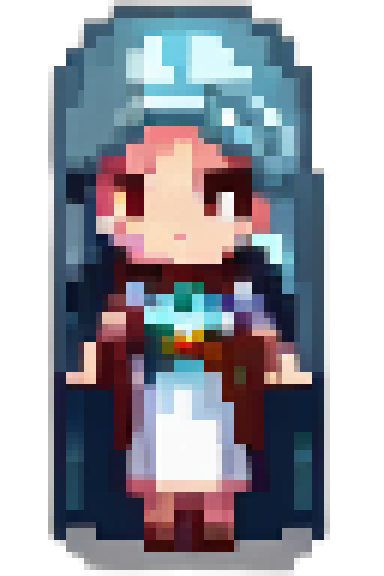


Back-view prompt: pixel art, single chibi character seen from behind, back of head visible, young prince swordsman, go...
Negative: front view, face, eyes, looking at viewer, facing camera, facing forward, portra...

Generating 3 test candidates...


  0%|          | 0/30 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


  0%|                                               | 0.00/176M [00:00<?, ?B/s]

  Candidate 0: quality=0.145 color_sim=0.58 seed=42


  0%|          | 0/30 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


  Candidate 1: quality=0.172 color_sim=0.61 seed=49


  0%|          | 0/30 [00:00<?, ?it/s]

  Candidate 2: quality=0.542 color_sim=0.64 seed=56

All 3 candidates (6x):
  #0 (q=0.145, cs=0.58, seed=42):


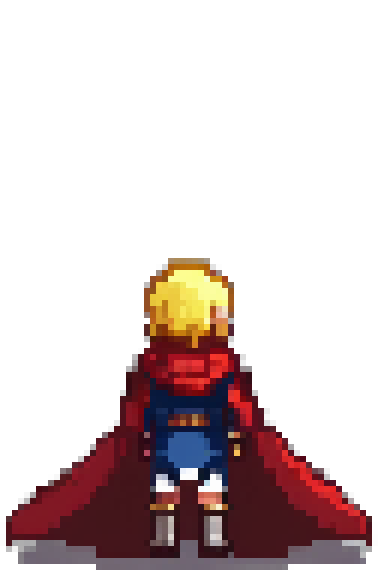

  #1 (q=0.172, cs=0.61, seed=49):


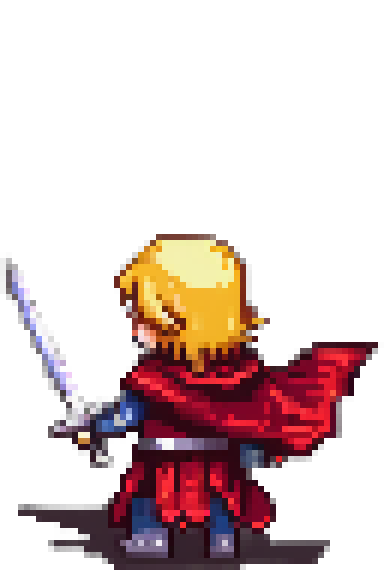

  #2 (q=0.542, cs=0.64, seed=56):


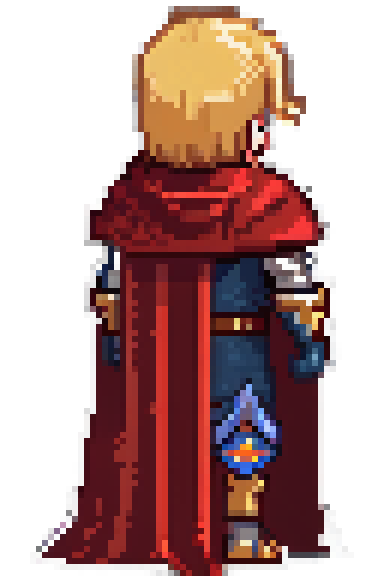


Front vs Best Back (6x):


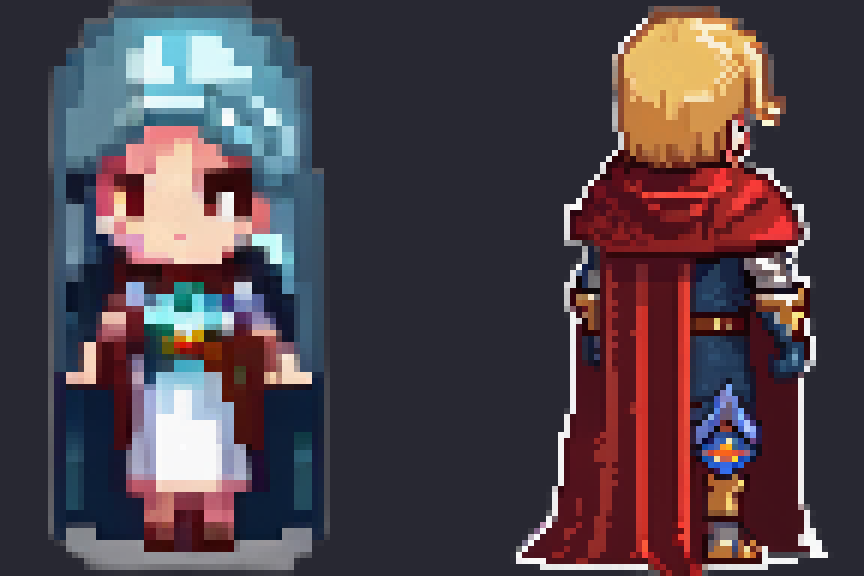


✓ Check: Does the back view show the BACK of the character (no face)?
  If yes → proceed to batch generation.
  If still showing front face → increase guidance or adjust prompts.


In [8]:
from IPython.display import display

test_entry = ENTRIES[0]  # hero
front_path = FRONT_DIR / f'{test_entry["name"]}.png'

if front_path.exists():
    front_img = Image.open(front_path)
    print('Front (6x):')
    display(front_img.resize((64*6, 96*6), Image.NEAREST))

print(f'\nBack-view prompt: {test_entry["prompt"][:100]}...')
print(f'Negative: {NEGATIVE[:80]}...')

# Generate 3 candidates and show all
print(f'\nGenerating 3 test candidates...')
test_results = []
for c in range(3):
    seed = 42 + c * 7
    gen = torch.Generator(device=DEVICE).manual_seed(seed)
    result = pipe(
        prompt=test_entry['prompt'], negative_prompt=NEGATIVE,
        width=512, height=768,
        num_inference_steps=30, guidance_scale=GUIDANCE,
        generator=gen,
    )
    raw = result.images[0]
    processed, score, fill_r, height_r = postprocess(raw)
    col_sim = color_similarity(front_path, processed) if front_path.exists() else 0.5
    test_results.append((processed, score, col_sim, seed))
    print(f'  Candidate {c}: quality={score:.3f} color_sim={col_sim:.2f} seed={seed}')

# Show all candidates at 6x
print('\nAll 3 candidates (6x):')
for i, (img, score, col_sim, seed) in enumerate(test_results):
    print(f'  #{i} (q={score:.3f}, cs={col_sim:.2f}, seed={seed}):')
    display(img.resize((64*6, 96*6), Image.NEAREST))

# Show front vs best back side by side
if front_path.exists():
    best = max(test_results, key=lambda x: x[1] * (0.4 + 0.6 * x[2]))
    print(f'\nFront vs Best Back (6x):')
    compare = Image.new('RGBA', (64*2 + 16, 96), (40, 40, 50, 255))
    compare.paste(front_img, (0, 0), front_img)
    compare.paste(best[0], (64+16, 0), best[0])
    display(compare.resize((compare.width*6, compare.height*6), Image.NEAREST))

free_vram()
print('\n✓ Check: Does the back view show the BACK of the character (no face)?')
print('  If yes → proceed to batch generation.')
print('  If still showing front face → increase guidance or adjust prompts.')

## 8. Generate All Back Views

In [9]:
out_dir = OUTPUT_BASE / 'overworld_characters'
out_dir.mkdir(parents=True, exist_ok=True)

tracker = ProgressTracker('owc_back_v2', OUTPUT_BASE)
remaining = sum(1 for e in ENTRIES if not tracker.is_done(f"{e['name']}_back"))
print(f'Back views: {len(ENTRIES)} total, {remaining} to generate\n')

t_start = time.time()
for i, entry in enumerate(ENTRIES):
    print(f'\n[{i+1}/{len(ENTRIES)}] {tracker.summary(len(ENTRIES))}')
    generate_back(entry, out_dir, tracker)

elapsed = time.time() - t_start
print(f'\nAll back views complete! ({elapsed/60:.1f} min total)')

Back views: 14 total, 14 to generate


[1/14] 0/14 done
  [gen] char_hero_back (30 steps, 3 candidates)


  0%|          | 0/30 [00:00<?, ?it/s]

        #0: quality=0.502 color=0.65 combined=0.397 seed=3517666848


  0%|          | 0/30 [00:00<?, ?it/s]

        #1: quality=0.568 color=0.65 combined=0.450 seed=3517681137


...

        #0: quality=0.482 color=0.60 combined=0.367 seed=3518262643


  0%|          | 0/28 [00:00<?, ?it/s]

        #1: quality=0.315 color=0.80 combined=0.278 seed=3518276941


  0%|          | 0/28 [00:00<?, ?it/s]

        #2: quality=0.509 color=0.78 combined=0.443 seed=3518290672
        PASS: combined=0.443 (quality=0.509, color=0.78)
        saved: char_guard_back.png (8 KB, 41.7s)

All back views complete! (10.6 min total)


## 9. Quality Review — Front vs Back

Front vs Back comparison (14 characters):

  char_hero             fill=0.58  height=0.98  color=0.65  PASS
  char_elf              fill=0.54  height=0.98  color=0.87  PASS
  char_treant           fill=0.66  height=0.95  color=0.90  PASS
  char_beast            fill=0.63  height=0.97  color=0.29  PASS
  char_merfolk          fill=0.70  height=0.99  color=0.89  PASS
  char_giant            fill=0.52  height=0.98  color=0.65  PASS
  char_dwarf            fill=0.44  height=0.98  color=0.58  PASS
  char_undead           fill=0.47  height=0.94  color=0.69  PASS
  char_npc_shop         fill=0.47  height=1.00  color=0.59  PASS
  char_npc_quest        fill=0.63  height=1.00  color=0.87  PASS
  char_npc_save         fill=0.64  height=0.99  color=0.91  PASS
  char_npc_info         fill=0.64  height=0.94  color=0.50  PASS
  char_npc_inn          fill=0.56  height=0.98  color=0.59  PASS
  char_guard            fill=0.51  height=1.00  color=0.78  PASS


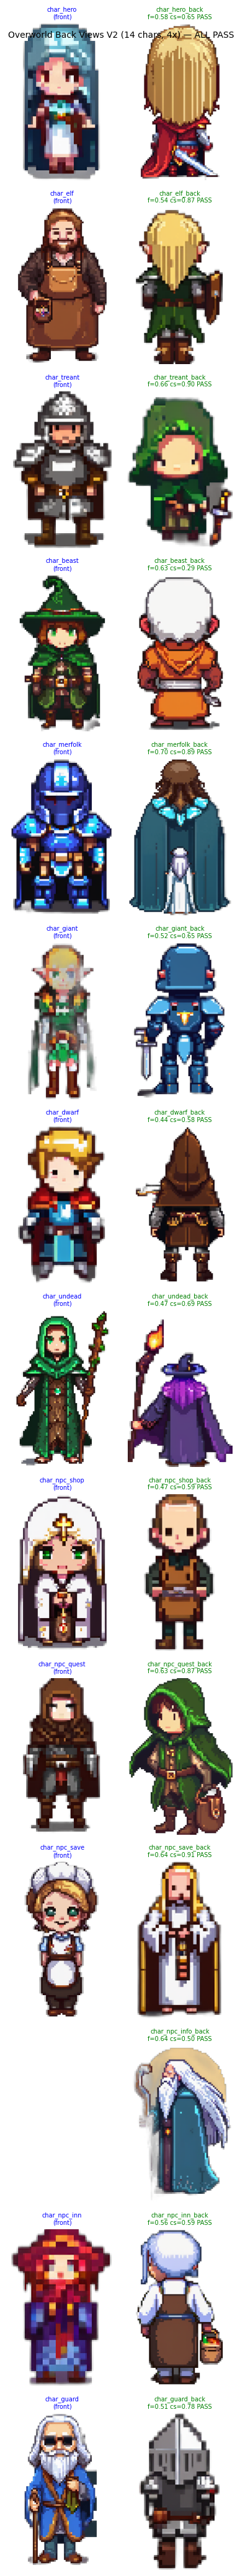


✓ All 14 back views passed!


In [10]:
import matplotlib.pyplot as plt

out_dir = OUTPUT_BASE / 'overworld_characters'
n = len(ENTRIES)
fig, axes = plt.subplots(n, 2, figsize=(4, n * 3))
if n == 1: axes = [axes]

print(f'Front vs Back comparison ({n} characters):\n')
all_pass = True
for i, entry in enumerate(ENTRIES):
    name = entry['name']
    front_path = out_dir / f'{name}.png'
    back_path = out_dir / f'{name}_back.png'

    ax_f, ax_b = axes[i]
    ax_f.axis('off'); ax_b.axis('off')

    if front_path.exists():
        f_img = Image.open(front_path)
        ax_f.imshow(f_img.resize((64*4, 96*4), Image.NEAREST))
        ax_f.set_title(f'{name}\n(front)', fontsize=7, color='blue')

    if back_path.exists():
        b_img = Image.open(back_path)
        score, fill_r, height_r = quality_score(b_img, TARGET_W, TARGET_H)
        col_sim = color_similarity(front_path, b_img)
        gate = 'PASS' if fill_r >= MIN_FILL_RATIO and height_r >= MIN_HEIGHT_RATIO else 'FAIL'
        if gate == 'FAIL': all_pass = False
        color = 'green' if gate == 'PASS' else 'red'
        ax_b.imshow(b_img.resize((64*4, 96*4), Image.NEAREST))
        ax_b.set_title(f'{name}_back\nf={fill_r:.2f} cs={col_sim:.2f} {gate}', fontsize=7, color=color)
        print(f'  {name:20s}  fill={fill_r:.2f}  height={height_r:.2f}  color={col_sim:.2f}  {gate}')
    else:
        all_pass = False
        ax_b.set_title(f'MISSING', fontsize=7, color='red')
        print(f'  {name:20s}  MISSING')

status = 'ALL PASS' if all_pass else 'ISSUES'
plt.suptitle(f'Overworld Back Views V2 ({n} chars, 4x) — {status}', fontsize=10)
plt.tight_layout()
plt.show()

if all_pass:
    print(f'\n✓ All {n} back views passed!')
else:
    print(f'\n⚠ Some items need attention.')

## 10. Export

```bash
bash scripts/import_colab_assets.sh ~/Downloads/owc_back_v2_output
bash scripts/force_restart_frontend.sh
```

In [11]:
import shutil

d = OUTPUT_BASE / 'overworld_characters'
if d.exists():
    back_keys = sorted(f.stem for f in d.glob('*_back.png'))
    front_keys = sorted(f.stem for f in d.glob('*.png') if '_back' not in f.stem and not f.stem.startswith('_'))
    print(f'Front views: {len(front_keys)}')
    print(f'Back views:  {len(back_keys)}')
    for k in back_keys:
        print(f'  {k}')

zip_path = '/content/owc_back_v2_output'
shutil.make_archive(zip_path, 'zip', str(OUTPUT_BASE))
print(f'\nZip: {os.path.getsize(zip_path + ".zip") / 1024:.1f} KB')

if ON_COLAB:
    from google.colab import files
    files.download(f'{zip_path}.zip')
else:
    print(f'Download: {zip_path}.zip')

Front views: 13
Back views:  14
  char_beast_back
  char_dwarf_back
  char_elf_back
  char_giant_back
  char_guard_back
  char_hero_back
  char_merfolk_back
  char_npc_info_back
  char_npc_inn_back
  char_npc_quest_back
  char_npc_save_back
  char_npc_shop_back
  char_treant_back
  char_undead_back

Zip: 8442.7 KB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>